# Kiwi 형태소 정규화 평가 노트북

경량 1차 매칭(`/query/destination`, `/query/info`)의 **질의 정규화** 품질을 실데이터 전수로 본다.
앱 런타임이 아니라 분석용이다.

- 데이터: `backend/resources/studio/thehyundai-seoul-dabeeo/stores_*.json` (12개 층). DB 시딩 불필요.
- 분석기: `kiwipiepy` (Kiwi), 정규화 코드는 앱의 `repositories/query_morph.py`를 그대로 호출한다.
- 설계·결정 근거: [docs/backend/native/KIWI.md](../../docs/backend/native/KIWI.md)
- 회귀 방지: [tests/unit/test_query_coverage.py](../tests/unit/test_query_coverage.py)가 같은 전수 검사를 테스트로 고정한다.

> 실행: backend/.venv 커널로 `Run All`. 모델 다운로드 없음(FAISS 노트북과 달리 torch를 쓰지 않는다).

**이 노트북이 답하는 질문**

1. 조사·어미가 붙은 질의가 전 매장에서 이름으로 복원되는가?
2. 매장명을 사용자 사전에 등록하는 것이 실제로 필요한가? (등록 전/후 비교)
3. 남는 실패는 무엇이고 왜 남는가?
4. 비용은 얼마인가?

In [1]:
# 셋업 — backend를 sys.path에 넣고 실데이터 매장명을 읽는다.
import sys, pathlib, json, time
import pandas as pd
import matplotlib.pyplot as plt

here = pathlib.Path.cwd()
backend = next(p for p in [here, *here.parents] if (p / 'app' / 'core' / 'database.py').exists())
sys.path.insert(0, str(backend))

# 한글 라벨이 깨지지 않게(Windows). 다른 OS면 가용 폰트로 교체.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from app.repositories import query_morph, query_search

STUDIO = backend / 'resources' / 'studio' / 'thehyundai-seoul-dabeeo'

def load_names():
    by_floor = {}
    for path in sorted(STUDIO.glob('stores_*.json')):
        floor = path.stem.replace('stores_', '').upper()
        raw = json.loads(path.read_text(encoding='utf-8'))
        items = raw if isinstance(raw, list) else raw.get('data') or raw.get('stores') or []
        by_floor[floor] = [str(i['name']) for i in items if isinstance(i, dict) and i.get('name')]
    return by_floor

NAMES_BY_FLOOR = load_names()
ALL_NAMES = [n for names in NAMES_BY_FLOOR.values() for n in names]
print(f'층 {len(NAMES_BY_FLOOR)}개, 매장 {len(ALL_NAMES)}건, 고유 이름 {len(set(ALL_NAMES))}건')

층 12개, 매장 1531건, 고유 이름 659건


## 1. 데이터 — 층별 매장 수

지하 6층~지상 6층. 지하가 주차·식품관이라 항목 수가 더 많다.

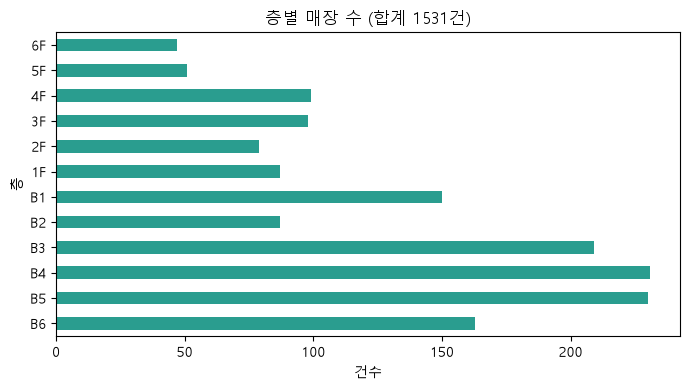

,매장 수,고유 이름
층,,
B6,163,69
B5,230,86
B4,231,90
B3,209,78
B2,87,76
B1,150,137
1F,87,76
2F,79,70
3F,98,89


In [2]:
floor_order = ['B6','B5','B4','B3','B2','B1','1F','2F','3F','4F','5F','6F']
counts = pd.DataFrame(
    [(f, len(NAMES_BY_FLOOR[f]), len(set(NAMES_BY_FLOOR[f]))) for f in floor_order],
    columns=['층', '매장 수', '고유 이름'],
).set_index('층')

ax = counts['매장 수'].plot(kind='barh', figsize=(7, 4), color='#2a9d8f')
ax.set_title(f'층별 매장 수 (합계 {counts["매장 수"].sum()}건)')
ax.set_xlabel('건수')
plt.tight_layout(); plt.show()
counts

## 2. 정규화 파이프라인

`query_search._normalize_query()` 는 2단계다.

1. `_strip_tail()` — 의문형 꼬리(`"몇 층이야"`, `"어디야"`, `"위치"` …)를 최대 1개 제거
2. `query_morph.normalize()` — Kiwi로 분석해 **조사·어미·용언 스팬만** 원문에서 지운다

여기서 비교할 두 조건은 **사용자 사전의 내용**만 다르다.

| 조건 | 사용자 사전 | 대응 |
|---|---|---|
| `등록 전` | 동의어 사전 16건만 | 최초 구현 |
| `등록 후` | 동의어 + 매장명 전체 | 현재 구현 (`_rank`가 `register_words` 호출) |

아래 `use_dictionary()`는 앱의 전역 싱글턴을 갈아끼워 **같은 정규화 코드**를 두 사전으로 돌린다.
정규화 로직을 노트북에 베껴 쓰지 않기 위한 장치다.

In [3]:
def use_dictionary(with_store_names: bool):
    """query_morph의 Kiwi 싱글턴을 새로 만든다. with_store_names면 매장명까지 등록."""
    query_morph._kiwi = None
    query_morph._load_failed = False
    query_morph._registered = set()
    t0 = time.perf_counter()
    query_morph._get_kiwi()            # 동의어 사전(16건)은 여기서 등록된다
    load_s = time.perf_counter() - t0

    reg_s = 0.0
    if with_store_names:
        t0 = time.perf_counter()
        query_morph.register_words(ALL_NAMES)
        reg_s = time.perf_counter() - t0
    return load_s, reg_s

load_s, reg_s = use_dictionary(True)
print(f'Kiwi 로드 {load_s:.2f}s, 매장명 {len(set(ALL_NAMES))}건 등록 {reg_s*1000:.1f}ms')

Kiwi 로드 0.63s, 매장명 659건 등록 0.9ms


## 3. 질의 변형 — 받침을 따진다

`"펜디이 어디야"`는 비문이다. 받침 없는 이름에는 `가/는`, 있는 이름에는 `이/은`을 붙여야
테스트가 실제 사용자 질의를 흉내 낸다. 초기 측정에서 이걸 빼먹어 실패 430건이 부풀려졌었다.

영문·숫자로 끝나는 이름(`MLB`, `7A`)에는 조사 변형을 적용하지 않는다.

In [4]:
def has_batchim(word):
    last = word.strip()[-1:]
    if not last or not ('가' <= last <= '힣'):
        return None                     # 한글로 안 끝남 → 조사 변형 제외
    return (ord(last) - 0xAC00) % 28 != 0

VARIANTS = [
    ('원문',        '',              ''),
    ('주격+의문',   '이 어디야',      '가 어디야'),
    ('보조사+층',   '은 몇 층이야',   '는 몇 층이야'),
    ('도달+희망',   '까지 가고 싶어', '까지 가고 싶어'),
    ('공백+어디',   ' 어디',          ' 어디'),
    ('공백+위치',   ' 위치',          ' 위치'),
    ('공백+알려줘', ' 알려줘',        ' 알려줘'),
]

def evaluate():
    """현재 사전 상태로 전 매장 × 전 변형을 돌려 (변형, 이름, 결과) 실패 목록을 만든다."""
    rows, fails = [], []
    for label, with_b, without_b in VARIANTS:
        checked = 0
        for name in ALL_NAMES:
            b = has_batchim(name)
            if b is None and with_b != without_b:
                continue
            checked += 1
            got = query_search._normalize_query(name + (with_b if b else without_b))
            if got != query_search._norm(name):
                fails.append({'변형': label, '매장명': name, '정규화 결과': got})
        rows.append({'변형': label, '검사': checked})
    return pd.DataFrame(rows).set_index('변형'), pd.DataFrame(fails)

use_dictionary(False)
before_counts, before_fails = evaluate()

use_dictionary(True)
after_counts, after_fails = evaluate()

def fail_counts(fails, index):
    if fails.empty:                     # 실패 0건이면 컬럼조차 없다
        return pd.Series(0, index=index, dtype=int)
    return fails['변형'].value_counts().reindex(index).fillna(0).astype(int)

summary = before_counts.copy()
summary['실패(등록 전)'] = fail_counts(before_fails, summary.index)
summary['실패(등록 후)'] = fail_counts(after_fails, summary.index)
summary['성공률(등록 후)'] = (1 - summary['실패(등록 후)'] / summary['검사']).map('{:.2%}'.format)
summary

,검사,실패(등록 전),실패(등록 후),성공률(등록 후)
변형,,,,
원문,1531,35,0,100.00%
주격+의문,645,39,0,100.00%
보조사+층,645,44,0,100.00%
도달+희망,1531,25,0,100.00%
공백+어디,1531,35,0,100.00%
공백+위치,1531,35,0,100.00%
공백+알려줘,1531,35,0,100.00%


## 4. 등록 전/후 비교

매장명을 사용자 사전에 넣지 않으면 **원문 질의조차** 깨진다. 이건 개선 실패가 아니라 **회귀**다.

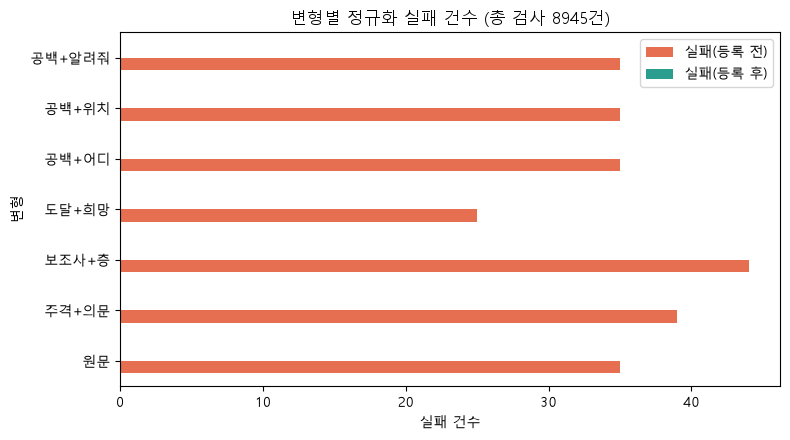

등록 전 총 실패: 248건 / 8945건
등록 후 총 실패: 0건 / 8945건


In [5]:
ax = summary[['실패(등록 전)', '실패(등록 후)']].plot(
    kind='barh', figsize=(8, 4.5), color=['#e76f51', '#2a9d8f']
)
ax.set_title(f'변형별 정규화 실패 건수 (총 검사 {summary["검사"].sum()}건)')
ax.set_xlabel('실패 건수')
plt.tight_layout(); plt.show()

print(f'등록 전 총 실패: {len(before_fails)}건 / {summary["검사"].sum()}건')
print(f'등록 후 총 실패: {len(after_fails)}건 / {summary["검사"].sum()}건')

## 5. 등록 전에 깨지던 이름 — 왜 깨지는가

미등록 고유명사의 **끝음절이 조사로 오인**되는 것이 원인이다.

- `리모와` → `리모` : `와`를 접속조사(JC)로
- `생로랑` → `생로` : `랑`을 접속조사로
- `발렌시아가` → `발렌시아` : `가`를 주격조사(JKS)로
- `미도` → `미` : `도`를 보조사(JX)로

원문 질의(`변형 = 원문`)에서 깨진 이름만 추리면 곧 **회귀 목록**이다.

In [6]:
regressed = (
    before_fails[before_fails['변형'] == '원문']
    .drop_duplicates('매장명')
    .set_index('매장명')[['정규화 결과']]
    .rename(columns={'정규화 결과': '등록 전'})
)
regressed['등록 후'] = [query_search._normalize_query(n) for n in regressed.index]
print(f'원문 질의인데 깨지던 이름: {len(regressed)}건')
regressed

원문 질의인데 깨지던 이름: 35건


,등록 전,등록 후
매장명,,
리모와,리모,리모와
생로랑,생로,생로랑
발렌시아가,발렌시아,발렌시아가
바이 레도,바이 레,바이 레도
미도,미,미도
알로,알,알로
위블로,위블,위블로
누니 주얼리,주얼리,누니 주얼리
더 캐시미어,캐시미어,더 캐시미어


## 6. 남는 실패와, 측정에서 한 번 속은 지점

등록 후 실패는 **0건**이다. 다만 여기엔 처음에 잘못 읽었던 사례가 하나 있어 기록해 둔다.

데이터에 `"물품 보관함"`(띄어쓰기)과 `"물품보관함"`(붙임)이 **둘 다** 존재한다.
**붙임 표기를 먼저 등록하면** Kiwi가 띄어쓴 쪽을 `물품 + 보관 + 하(XSV) + ㅁ(ETN)` 으로 쪼개
`"함"`이 어미로 제거된다(`add_user_word`의 `score`를 올려도 안 바뀐다).

최초 측정 스크립트가 `set(names)`로 등록해 **해시 순서상 붙임 표기가 먼저** 들어갔고,
그래서 실패로 보였다. 앱은 `_load_stores()`가 준 **리스트 순서**로 등록하므로 띄어쓴 쪽이 먼저다.
즉 이 실패는 앱 동작이 아니라 측정 코드의 아티팩트였다.

**남는 취약점**: 결과가 등록 순서에 의존한다. Studio 데이터 순서가 바뀌면 tier 0 → tier 2로
내려갈 수 있다(매칭 자체는 유지). 근본 해결은 데이터에서 표기를 하나로 합치는 것이다.

In [7]:
print('등록 후 남은 실패:', len(after_fails), '건')

kiwi = query_morph._get_kiwi()
print('현재(띄어쓴 표기 먼저 등록):', [(t.form, t.tag) for t in kiwi.tokenize('물품 보관함이 어디야')])

# 순서를 뒤집으면 어떻게 되는지 재현한다.
from kiwipiepy import Kiwi
flipped = Kiwi()
flipped.add_user_word('물품보관함', 'NNP')
flipped.add_user_word('물품 보관함', 'NNP')
print('뒤집으면(붙임 표기 먼저):    ', [(t.form, t.tag) for t in flipped.tokenize('물품 보관함이 어디야')])

# 순서가 뒤집혀도 부분 일치(tier 2)로는 잡힌다 — 사용자 영향이 없음을 확인.
from app.models import Floor, Store
floor = Floor(id='F1', building_id='B', name='1F', level=1)
store = Store(id='s1', floor_id='F1', name='물품 보관함',
              centroid_x_m=0.0, centroid_y_m=0.0, entrance_node_id='N-1')
scored = query_search._rank([(store, floor)], '물품 보관함이 어디야')
print('매칭:', bool(scored), '| tier =', scored[0][0] if scored else None, '(0=정확 이름, 2=부분 일치)')

등록 후 남은 실패: 0 건
현재(띄어쓴 표기 먼저 등록): [('물품 보관함', 'NNP'), ('이', 'JKS'), ('어디', 'NP'), ('이', 'VCP'), ('야', 'EF')]


뒤집으면(붙임 표기 먼저):     [('물품', 'NNG'), ('보관', 'NNG'), ('하', 'XSV'), ('ᆷ', 'ETN'), ('이', 'JKS'), ('어디', 'NP'), ('이', 'VCP'), ('야', 'EF')]
매칭: True | tier = 0 (0=정확 이름, 2=부분 일치)


## 7. 전 층 편의시설 — 수직 이동수단

`엘리베이터`·`에스컬레이터`는 12개 층 전부에, `화장실`은 11개 층에 존재한다.
층 목록 응답(`match_info`)이 이 데이터 위에서 동작하므로 정규화가 흔들리면 층 목록도 흔들린다.

In [8]:
FACILITIES = ['엘리베이터', '에스컬레이터', '화장실', '장애인화장실']
TEMPLATES = ['{}', '{} 어디', '{}{조사} 어디야', '{}{조사2} 몇 층이야', '{}까지 가고 싶어', '{} 급해']

rows = []
for fac in FACILITIES:
    b = has_batchim(fac)
    floors = [f for f in floor_order if fac in NAMES_BY_FLOOR[f]]
    ok = 0
    for tpl in TEMPLATES:
        q = tpl.format(fac, 조사='이' if b else '가', 조사2='은' if b else '는')
        ok += query_search._normalize_query(q) == fac
    rows.append({'시설': fac, '총 개수': ALL_NAMES.count(fac), '존재 층 수': len(floors),
                 '층': ' '.join(floors), '정규화 성공': f'{ok}/{len(TEMPLATES)}'})
pd.DataFrame(rows).set_index('시설')

,총 개수,존재 층 수,층,정규화 성공
시설,,,,
엘리베이터,60,12,B6 B5 B4 B3 B2 B1 1F 2F 3F 4F 5F 6F,6/6
에스컬레이터,43,12,B6 B5 B4 B3 B2 B1 1F 2F 3F 4F 5F 6F,6/6
화장실,19,11,B6 B4 B3 B2 B1 1F 2F 3F 4F 5F 6F,6/6
장애인화장실,8,7,B6 B4 B3 1F 3F 5F 6F,6/6


## 8. 비용

사전 등록은 첫 질의에서 한 번만 일어난다(1ms 미만). 정규화는 질의당 1ms 안쪽이고,
같은 요청에서 도는 매장 1531건 스캔·DB 조회에 비하면 지배적이지 않다.

In [9]:
use_dictionary(True)
sample = [n + '이 어디야' for n in ALL_NAMES]

t0 = time.perf_counter()
for q in sample:
    query_search._normalize_query(q)
elapsed = time.perf_counter() - t0

cost = pd.DataFrame([
    {'항목': 'Kiwi 인스턴스 로드', '값': f'{load_s:.2f} s', '빈도': '프로세스당 1회(지연 로드)'},
    {'항목': f'매장명 {len(set(ALL_NAMES))}건 사전 등록', '값': f'{reg_s*1000:.1f} ms', '빈도': '첫 질의 1회'},
    {'항목': '질의 1건 정규화', '값': f'{elapsed/len(sample)*1e6:.0f} µs', '빈도': '매 질의'},
    {'항목': f'{len(sample)}건 일괄 정규화', '값': f'{elapsed:.2f} s', '빈도': '전수 테스트'},
]).set_index('항목')
cost

,값,빈도
항목,,
Kiwi 인스턴스 로드,0.63 s,프로세스당 1회(지연 로드)
매장명 659건 사전 등록,0.9 ms,첫 질의 1회
질의 1건 정규화,930 µs,매 질의
1531건 일괄 정규화,1.42 s,전수 테스트


## 9. 결론

1. **매장명 사용자 사전 등록은 선택이 아니라 전제 조건이다.** 등록하지 않으면 원문 질의에서만
   35건이 깨지는 회귀가 생긴다. 비용은 1ms 남짓이다.
2. **등록 후 전수 실패는 0건이다.** 남는 취약점은 표기가 중복된 이름(`물품 보관함` / `물품보관함`)의
   **사전 등록 순서 의존성**이고, 순서가 뒤집혀도 부분 일치로 매칭은 유지된다.
   근본 해결은 Studio 데이터에서 표기를 하나로 합치는 것이다.
3. **측정 코드가 두 번 거짓말했다.** (a) 받침을 안 따진 비문 변형(`펜디이 어디야`)이 실패 430건을
   만들었고, (b) `set()` 순회 순서가 없는 실패 1건을 만들었다.
   수치를 믿기 전에 **질의 문법과 입력 순서**를 먼저 고정해야 한다.
4. **개념 질의는 여전히 형태소의 몫이 아니다.** `"밥 먹을 데"` → `"밥 데"`.
   이건 임베딩 2차([FAISS.md](../../docs/backend/native/FAISS.md))가 담당하며,
   2차에는 **질의 원문**이 전달되므로 이 변경의 영향을 받지 않는다.